# Metagenomic Analyses of the Longitudinal Acne Study
## Relative Abundance Plots

Date created: 10/17/2024

Notebook author: Yang Chen

Data analysis by: Yang Chen and Britta De Pessemier

This notebook plots the following:

- Metagenomic relative abundance plots of metagenome assembled genomes from a subset of acne lesional and non-lesional samples

In [384]:
# Import Python packages
import pandas as pd
import numpy as np
import biom
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import os
from matplotlib.colors import ListedColormap
from scipy.stats import pearsonr
from scipy.stats import zscore


In [385]:
# Switch this to Genus to make the Genus level plots and Species to make the  plots
# taxa_level = 'Genus'
taxa_level = 'Species'

In [386]:
# Load the metadata
metadata_path = '../Metadata/metadata_final_18062024.tsv'
metadata = pd.read_csv(metadata_path, sep='\t')

In [387]:
# Define paths to the collapsed taxa tables
biom_paths = {
    # 'veba_MAGs_genus': '../Data/metaG/Tables/metaG_mags_genus.biom',
    'veba_MAGs_species': '../Data/metaG/Tables/metaG_mags_species.biom'
    # 'qiita_wolr2' : '../Data/metaG/Tables/metaG_wolr2_micov-filt_speces.biom',
    # 'qiita_rs210' : '../Data/metaG/Tables/metaG_rs210_micov-filt_speces.biom',
    # 'qiita_rs210': '../Data/metaG/Tables/metaG_rs210_micov-filt_species.biom'}
}

In [388]:
# Predefined color palette for specific families
taxa_colors = {
    ' s__Cutibacterium acnes': '#ffa505',  # Bright orange
    ' s__Malassezia spp.': '#ec8cbf',     # Light purple pink
    ' s__Lawsonella cleavelandensis': '#70a8dc',      # Light blue
    ' s__Corynebacterium spp.': '#92f0f0',      # Fluorescent light blue
    ' s__Streptococcus spp.': '#e2b46c',    # Beige
    ' s__Micrococcus luteus': '#ffe59a',        # Pastel yellow
    ' s__Neisseria cerebrosa': '#f6475f',         # Redish pink
    ' s__Porphyromonas pasteri': '#c5bce0',         # Pastel purplish
    ' s__Actinomyces spp.': '#f4cccd',  # Light pink
    ' s__Alloprevotella spp.': '#bcbcbc',  # Light gray
    ' s__Psychrobacter spp.': '#daead3',  # Light greenish gray
    ' s__Marinomonas spp.' : '#9FE2BF', # Seafoam green
    'Others': '#ededed'                 # White
}

In [389]:
# A list of unique colors to use for taxa not predefined
unique_colors = sns.color_palette("deep", n_colors=20).as_hex()
unique_color_iter = cycle(unique_colors)  # Iterator to cycle through unique colors

In [390]:
# Function to load BIOM table, collapse by taxa, and sort rows by row sum
def load_biom_table(biom_path):
    table = biom.load_table(biom_path)
    df = pd.DataFrame(table.matrix_data.toarray(),
                      index=table.ids(axis='observation'),
                      columns=table.ids(axis='sample'))
    
    # Sort rows by row sum in descending order
    df['row_sum'] = df.sum(axis=1)
    df = df.sort_values(by='row_sum', ascending=False)
    
    # Drop the 'row_sum' column before returning
    df = df.drop(columns=['row_sum'])
    
    return df

In [391]:
# Function to determine the top 15 in taxa level and collapse the rest as "Others"
def collapse_top_10(df):
    top_families = df.sum(axis=1).nlargest(10).index  # Select top 15 families
    df_top = df.loc[top_families]
    df_top.loc['Others'] = df.loc[~df.index.isin(top_families)].sum()
    return df_top

In [392]:
# Function to get or assign colors to families
def get_taxa_colors(families, global_taxa_color_map):
    for taxa in families:
        if taxa not in global_taxa_color_map:
            if taxa in taxa_colors:
                global_taxa_color_map[taxa] = taxa_colors[taxa]
            else:
                global_taxa_color_map[taxa] = next(unique_color_iter)  # Assign a new unique color
    return global_taxa_color_map

In [393]:
def plot_relative_abundance(df, metadata, group_column, output_dir, biom_key, taxa_color_map):
    # Average by group
    df_grouped = df.groupby(metadata[group_column], axis=1).mean()
    
    # Reorder the columns to Acne Non-lesional then Lesional
    desired_order = ['Acne_NL', 'Acne_L']
    df_grouped = df_grouped[desired_order]

    # Create output file paths
    output_png_file = os.path.join(output_dir, f'{biom_key}_{taxa_level}_relative_abundance_plot.png')  # Save as png
    output_svg_file = os.path.join(output_dir, f'{biom_key}_{taxa_level}_relative_abundance_plot.svg')  # Save as svg

    # Set plot title based on biom_key
    if biom_key == 'veba_MAGs_species':
        plot_title = f'metaG Relative Abundance'
    elif biom_key == 'qiita_wolr2':
        plot_title = f'metaG wolr2 {taxa_level} Level Relative Abundance'
    elif biom_key == 'qiita_rs210':
        plot_title = f'metaG rs210 {taxa_level} Level Relative Abundance'
    elif biom_key == 'veba_MAGs':
        plot_title = f'metaG {taxa_level} Level Relative Abundance'

    # Plot
    ax = df_grouped.T.plot(kind='bar', stacked=True, figsize=(10, 10),
                           width=0.8,  # Bars closer together
                           color=[taxa_color_map.get(fam, '#ADD8E6') for fam in df_grouped.index])

    plt.ylabel('Relative Abundance', fontsize=20)
    plt.xlabel(' ')
    plt.title(plot_title, fontsize=22)

    new_labels = ['Acne\nNon-lesional\n(n=12)', 'Acne\nLesional\n(n=12)']

    # Set the new x-tick labels
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=20)

    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=16)
    plt.tight_layout()

    plt.savefig(output_png_file, format='png', dpi=600)  # Save as png
    plt.savefig(output_svg_file, format='svg')  # Save as svg
    plt.show()

    plt.close()


In [394]:
# Switch this to Genus to make the Genus level plots and Species to make the  plots
# taxa_level = 'Genus'
taxa_level = 'Species'

In [395]:
# Define paths to the collapsed taxa tables
biom_paths = {
    'veba_MAGs': '../Data/metaG/Tables/metaG_mags_species.biom'}

In [396]:
# Predefined color palette for specific species
taxa_colors = {
    ' s__Cutibacterium acnes': '#ffa505',  # Bright orange
    ' s__Malassezia spp.': '#ec8cbf',     # Light purple pink
    ' s__Lawsonella cleavelandensis': '#70a8dc',      # Light blue
    ' s__Corynebacterium spp.': '#92f0f0',      # Fluorescent light blue
    ' s__Streptococcus spp.': '#e2b46c',    # Beige
    ' s__Micrococcus luteus': '#ffe59a',        # Pastel yellow
    ' s__Neisseria cerebrosa': '#f6475f',         # Redish pink
    ' s__Porphyromonas pasteri': '#c5bce0',         # Pastel purplish
    ' s__Actinomyces spp.': '#f4cccd',  # Light pink
    ' s__Alloprevotella spp.': '#bcbcbc',  # Light gray
    ' s__Psychrobacter spp.': '#daead3',  # Light greenish gray
    ' s__Marinomonas spp.' : '#9FE2BF', # Seafoam green
    'Others': '#ededed'                 # White
}

/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_59954/3709050885.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_grouped = df.groupby(metadata[group_column], axis=1).mean()


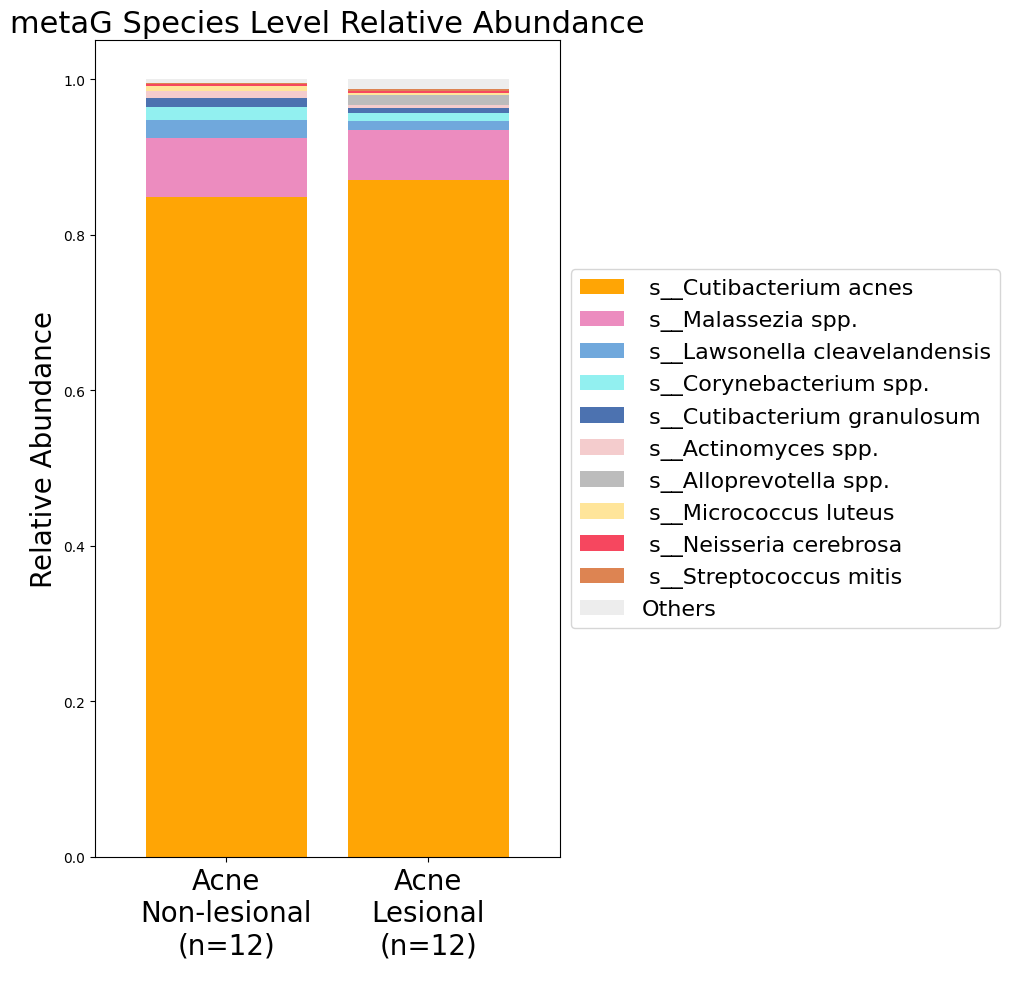

In [397]:
# Process both BIOM files
global_taxa_color_map = {}  # Store colors assigned to families across both datasets
for biom_key, biom_path in biom_paths.items():
    # Load and process the BIOM table
    df = load_biom_table(biom_path)
    df_top_10 = collapse_top_10(df)  # Now using the top 15 function
    
    # Define the output directory for the current biom_key
    output_dir = '../Figures/metaG_Figures'
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    
    # Merge with metadata
    metadata_subset = metadata.set_index('SampleID').loc[df.columns]  # Assuming SampleID in metadata matches samples in BIOM table
    
    # Generate or retrieve colors for the top families in this dataset
    global_taxa_color_map = get_taxa_colors(df_top_10.index, global_taxa_color_map)
    
    # Plot the results and save in the respective folder 
    plot_relative_abundance(df_top_10, metadata_subset, 'group', output_dir, biom_key, global_taxa_color_map)

### MAG completeness vs relative abundance

In [398]:
completeness_df = pd.read_csv('../Data/metaG/VEBA_analysis/output_files/MAG_vs_completeness.tsv', sep='\t')

# Set the 'sample_mag' column as the index
completeness_df = completeness_df.set_index('sample_mag')
completeness_df.index.name = None

completeness_df

,Completeness
LAMI_RD304_D0_C1_S1_L005__METABAT2__P.1__bin.2,99.94
LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bin.001,99.98
LAMI_RD304_D11_C1_S3_L005__CONCOCT__P.1__13,99.89
LAMI_RD304_D14_C3_S4_L005__MAXBIN2-107__P.1__bin.001,99.65
LAMI_RD304_D28_C3_S5_L005__CONCOCT__P.1__20,87.82
LAMI_RD304_D28_C3_S5_L005__CONCOCT__P.1__9,99.98
LAMI_RD304_D7_C1_S6_L005__METABAT2__P.1__bin.3,99.70
LAMI_RD306_D0_C3_S7_L005__MAXBIN2-40__P.1__bin.001,99.95
LAMI_RD306_D0_C3_S7_L005__METABAT2__P.1__bin.2,80.39
LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__14_sub,54.07


In [399]:
# Read in SLCs table from veba
SLCs_raw = pd.read_csv('../Data/metaG/VEBA_analysis/output_files/X_mags.with_taxonomy.with_slcs_name.csv')

# Set the 'sample_mag' column as the index
SLCs_raw = SLCs_raw.set_index('sample_mag')
SLCs_raw.index.name = None

# Remove unneeded columns from this 
columns_to_remove = ['SLC', 'organism_type', 'taxonomy', 'name']
SLCs = SLCs_raw.drop(columns=columns_to_remove, errors='ignore')

# Add a new column 'row_sum' that contains the sum of all values in each row
SLCs['Counts_sum'] = SLCs.sum(axis=1)

# Remove columns that start with 'LAMI'
SLCs = SLCs.drop(columns=[col for col in SLCs.columns if col.startswith('LAMI')])

SLCs

,Counts_sum
LAMI_RD306_D0_C3_S7_L005__MAXBIN2-40__P.1__bin.001,11022680
LAMI_RD306_D0_C3_S7_L005__METABAT2__P.1__bin.2,752492
LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__14_sub,103617
LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__26,764983
LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__27,700889
...,...
LAMI_RD310_D16_C2_S22_L005__METABAT2__P.1__bin.1,7056566
LAMI_RD310_D21_C2_S23_L005__CONCOCT__P.1__37,8994645
LAMI_RD310_D7_C3_S24_L005__GENOMAD__Virus.1,7562
LAMI_RD310_D7_C3_S24_L005__METABAT2__P.1__bin.1,7289943


In [400]:
# Concatenate SLCs and completeness_df by matching indices
mag_completeness_vs_abundance = pd.concat([SLCs, completeness_df], axis=1)
mag_completeness_vs_abundance['Counts_sum_log'] = np.log(mag_completeness_vs_abundance['Counts_sum'])

# Remove rows where Completeness is NaN
mag_completeness_vs_abundance = mag_completeness_vs_abundance.dropna(subset=['Completeness'])

In [401]:
# Add name column back
mag_completeness_vs_abundance = mag_completeness_vs_abundance.join(
    SLCs_raw[['name']], 
    how='left'
)

# Remove rows where the 'name' column is 'Other (combined)'
mag_completeness_vs_abundance = mag_completeness_vs_abundance[mag_completeness_vs_abundance['name'] != 'Other (combined)']

mag_completeness_vs_abundance

,Counts_sum,Completeness,Counts_sum_log,name
LAMI_RD306_D0_C3_S7_L005__MAXBIN2-40__P.1__bin.001,11022680,99.95,16.215466,Cutibacterium acnes
LAMI_RD306_D0_C3_S7_L005__METABAT2__P.1__bin.2,752492,80.39,13.531146,Cutibacterium granulosum
LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__27,700889,99.21,13.460105,Lawsonella cleavelandensis
LAMI_RD306_D11_C1_S8_L005__MAXBIN2-40__P.1__bin.001,11065070,99.95,16.219304,Cutibacterium acnes
LAMI_RD306_D11_C1_S8_L005__METABAT2__P.1__bin.4,635908,85.50,13.362809,Cutibacterium granulosum
LAMI_RD306_D14_C1_S9_L005__MAXBIN2-107__P.1__bin.001,11248249,99.98,16.235723,Cutibacterium acnes
LAMI_RD306_D14_C3_S10_L005__CONCOCT__P.1__23,337397,54.89,12.729016,Corynebacterium spp.
LAMI_RD306_D14_C3_S10_L005__MAXBIN2-107__P.1__bin.001,11137623,99.97,16.225839,Cutibacterium acnes
LAMI_RD306_D14_C3_S10_L005__MAXBIN2-107__P.1__bin.002,839570,99.94,13.640645,Lawsonella cleavelandensis
LAMI_RD306_D14_C3_S10_L005__MAXBIN2-40__P.1__bin.006_sub,228232,52.06,12.338118,Neisseria spp.


In [402]:
# See all unique values in name column
mag_completeness_vs_abundance['name'].value_counts()

name
Cutibacterium acnes           22
Cutibacterium granulosum       5
Malassezia spp.                5
Lawsonella cleavelandensis     4
Corynebacterium spp.           4
Neisseria spp.                 2
Micrococcus spp.               1
Streptococcus mitis            1
Name: count, dtype: int64

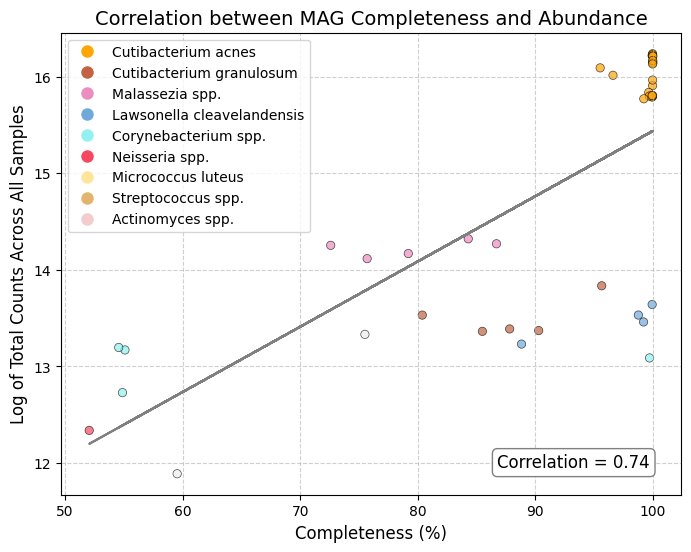

In [404]:
# Define the color mapping for specific names
color_map = {
    'Cutibacterium acnes': '#ffa505',  # Bright orange
    'Cutibacterium granulosum': '#C36241', # Dark orange
    'Malassezia spp.': '#ec8cbf',     # Light purple pink
    'Lawsonella cleavelandensis': '#70a8dc',      # Light blue
    'Corynebacterium spp.': '#92f0f0',      # Fluorescent light blue
    'Neisseria spp.': '#f6475f',         # Redish pink
    'Micrococcus luteus': '#ffe59a',        # Pastel yellow
    'Streptococcus spp.': '#e2b46c',    # Beige
    'Actinomyces spp.': '#f4cccd',  # Light pink
}

# Assign colors
colors = mag_completeness_vs_abundance['name'].map(color_map).fillna('#ededed')

# Fit the best-fit line
x = mag_completeness_vs_abundance['Completeness']
y = mag_completeness_vs_abundance['Counts_sum_log']
m, b = np.polyfit(x, y, 1)  # Linear regression
predicted_y = m * x + b  # Predicted values

# Calculate residuals
residuals = y - predicted_y

# Calculate IQR to identify residual outliers
Q1 = residuals.quantile(0.25)
Q3 = residuals.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out residual outliers
filtered_df = mag_completeness_vs_abundance[(residuals >= lower_bound) & (residuals <= upper_bound)]

# Assign colors to the filtered DataFrame
colors = filtered_df['name'].map(color_map).fillna('#ededed')

# Scatter plot with filtered data
plt.figure(figsize=(8, 6))
plt.scatter(
    filtered_df['Completeness'], 
    filtered_df['Counts_sum_log'], 
    color=colors, 
    edgecolor='black',
    linewidth=0.5,
    alpha=0.7, 
    label=None
)

# Best-fit line with filtered data
x_filtered = filtered_df['Completeness']
y_filtered = filtered_df['Counts_sum_log']
m_filtered, b_filtered = np.polyfit(x_filtered, y_filtered, 1)  # Linear regression on filtered data
plt.plot(x_filtered, m_filtered * x_filtered + b_filtered, color='grey', label='Best Fit Line')

# Recalculate correlation with filtered data
correlation_filtered = np.corrcoef(x_filtered, y_filtered)[0, 1]

# Add correlation to the plot at bottom right
plt.text(
    0.95, 0.05,  # Bottom-right corner
    f'Correlation = {correlation_filtered:.2f}', 
    fontsize=12, 
    transform=plt.gca().transAxes, 
    horizontalalignment='right', 
    verticalalignment='bottom', 
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="grey", facecolor="white")
)

# Add title and labels
plt.title('Correlation between MAG Completeness and Abundance', fontsize=14)
plt.xlabel('Completeness (%)', fontsize=12)
plt.ylabel('Log of Total Counts Across All Samples', fontsize=12)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[name], markersize=10) 
    for name in color_map
]
plt.legend(handles, color_map.keys(), loc='best', fontsize=10)

# Save the plot
plt.savefig('../Figures/metaG_Figures/completeness_vs_log_counts_filtered_residuals.png', dpi=600)
plt.show()
